# Определение возрастной категории пользователей по данным о веб-активности

*Проект по линейным моделям машинного обучения для компании «Йети»*

Автор: Якунин Михаил

Дата: __ июля 2026 г.

***По этой ссылке можно посмотреть проекта и скачать последнюю версию: https://github.com/MEYakunin/Sprint13_Yeti_Age_Prediction.git***

## Цель проекта

Разработать модель машинного обучения, которая на основе анонимизированных данных о поведении пользователей в интернете (логи посещений сайтов, активность с рекламой, тип устройства, глубина просмотра, использование облачных сервисов) автоматически определяет возрастную категорию пользователя.

Целевая переменная — age_category с пятью классами:
- 0: младше 18 лет
- 1: 18–25 лет
- 2: 26–40 лет
- 3: 41–55 лет
- 4: 56 лет и старше

## Задача проекта

Построить и обучить линейный классификатор (LogisticRegression или SVC) для предсказания возрастной категории пользователя по его цифровому следу. Обеспечить macro F1 ≥ 0.75, создать признаки из логов посещений, правильно разделить выборку, сохранить пайплайн и функцию объединения данных для внедрения.

## Описание данных

В проекте используются шесть CSV-файлов, каждый из которых содержит различные аспекты поведения пользователей. Все данные анонимизированы и не содержат прямой идентификации личности.

**1. `users` (целевая переменная)**
- `user_id` — уникальный идентификатор пользователя.
- `age_category` — целевая переменная (класс возраста):
  - `0`: младше 18 лет
  - `1`: 18–25 лет
  - `2`: 26–40 лет
  - `3`: 41–55 лет
  - `4`: 56 лет и старше

**2. `visits` (лог посещений сайтов)**
- `date` — дата посещения.
- `daytime` — время суток (утро, день, вечер, ночь).
- `session_id` — уникальный идентификатор сессии.
- `user_id` — идентификатор пользователя.
- `website_category` — анонимизированная категория сайта (десятки категорий).

**3. `ads_activity` (активность с рекламой)**
- `user_id`
- `ads_activity` — частота кликов по рекламе (очень редко, редко, умеренно, часто, очень часто).

**4. `surf_depth` (глубина просмотра)**
- `user_id`
- `surf_depth` — категория глубины перехода по сайтам (поверхностно, средне, глубоко).

**5. `primary_device` (основное устройство)**
- `user_id`
- `primary_device` — тип основного устройства для выхода в интернет (например, десктоп, мобильный телефон, планшет).

**6. `cloud_usage` (использование облачных сервисов)**
- `user_id`
- `cloud_usage` — бинарный признак (`True` / `False`), указывающий, пользуется ли пользователь облачными ресурсами (например, Яндекс 360).

**Особенности:**
- Таблица `visits` содержит множество строк на одного пользователя (история посещений). Остальные таблицы имеют по одной записи на `user_id`.
- В данных могут быть пропуски (особенно в `cloud_usage`), которые потребуют обработки.
- Целевая переменная может быть несбалансированной — это будет проверено на этапе EDA.

## Содержание <a id=content></a>

1. [Подготовка среды и библиотек](#1)
2. [Исследовательский анализ данных (EDA)](#2)
3. [Предобработка данных](#3)
4. [Создание новых признаков (Feature Engineering)](#4)
5. [Разделение данных (стратифицированное по пользователям)](#5)
6. [Предобработка признаков (пайплайн)](#6)
7. [Отбор признаков](#7)
8. [Обучение базовой модели (Baseline)](#8)
9. [Обучение основных моделей и подбор гиперпараметров](#9)
10. [Оценка на тестовой выборке](#10)
11. [Подготовка артефактов для внедрения](#11)
12. [](#12)

## [Этап 1. Подготовка среды и библиотек <a id=1></a>](#content)

In [8]:
# Установка необходимых библиотек
# !pip install -r requirements.txt

In [ ]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [10]:
# Устанавливаем константные параметры
RANDOM_STATE = 988

# Пути к данным
DATA_PATH = 'data/'
FILES = {
    'users': 'ds_s13_users.csv',
    'visits': 'ds_s13_visits.csv',
    'ads': 'ads_activity.csv',
    'surf': 'surf_depth.csv',
    'device': 'primary_device.csv',
    'cloud': 'cloud_usage.csv'
}

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

## [Этап 2. Исследовательский анализ данных (EDA) <a id=2></a>](#content)

### 2.1 Загрузка данных и первичная информация о данных

In [11]:
# Загружаем все CSV-файлы
users = pd.read_csv(DATA_PATH + FILES['users'])
visits = pd.read_csv(DATA_PATH + FILES['visits'])
ads = pd.read_csv(DATA_PATH + FILES['ads'])
surf = pd.read_csv(DATA_PATH + FILES['surf'])
device = pd.read_csv(DATA_PATH + FILES['device'])
cloud = pd.read_csv(DATA_PATH + FILES['cloud'])

# Создание словаря c датафреймами
dataframes = {
    'users': users,
    'visits': visits,
    'ads': ads,
    'surf': surf,
    'device': device,
    'cloud': cloud
}

In [12]:
# Создаем функцию для отображения данных
def primary_info(df, name):
    print('='*50)
    print(f'Информация о таблице: {name}')
    print('='*50)
    display(df.head(5))
    df.info()
    display(df.describe(include='all').T)
    print()

In [13]:
 # Выводим первичную информацию 
for name, df in dataframes.items():
    primary_info(df, name)

Информация о таблице: users


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,5913,5826,ee47-db686342605ccf3ce244-088514e9,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_category,5913.0,NaN,NaN,NaN,2.441569,1.380322,0.0,2.0,3.0,4.0,4.0



Информация о таблице: visits


...

,count,unique,top,freq
user_id,5669,5669,d602-ec060db7597a6b8cd4e7-aa625896,1
primary_device,5669,4,смартфон,3083



Информация о таблице: cloud


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB


,count,unique,top,freq
user_id,5680,5680,a1e4-91c8a52eb855595e653f-298ce305,1
cloud_usage,5680,2,True,2951


### 2.2 Анализ целевой переменной

In [14]:
# Распределение классов
age_counts = users['age_category'].value_counts().sort_index()
age_percent = users['age_category'].value_counts(normalize=True).sort_index() * 100

Распределение age_category:
  Категория 0: 863 (14.6%)
  Категория 1: 520 (8.8%)
  Категория 2: 1467 (24.8%)
  Категория 3: 1269 (21.5%)
  Категория 4: 1794 (30.3%)


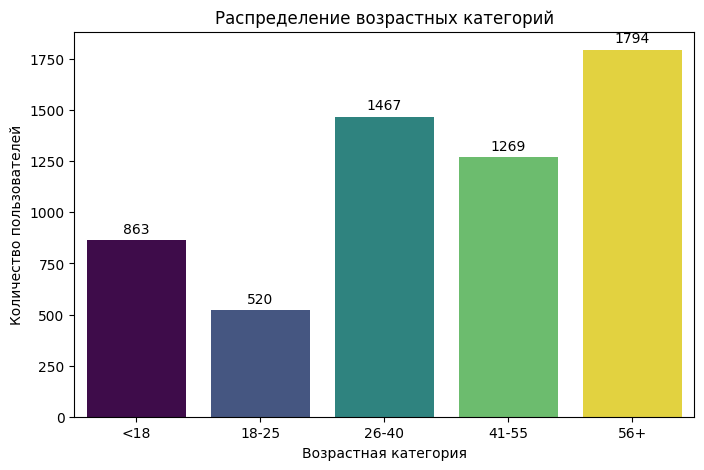

In [24]:
print("Распределение age_category:")
for cat, count, pct in zip(age_counts.index, age_counts.values, age_percent.values):
    print(f"  Категория {cat}: {count} ({pct:.1f}%)")

# Построение графика
plt.figure(figsize=(8,5))
ax = sns.countplot(data=users, x='age_category', hue='age_category', 
                   palette='viridis', legend=False)
plt.title('Распределение возрастных категорий')
plt.xlabel('Возрастная категория')
plt.ylabel('Количество пользователей')
plt.xticks(ticks=range(5), labels=['<18', '18-25', '26-40', '41-55', '56+'])

# Добавление значений на столбцы
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.show()

### 2.3 Аназиз данных

In [ ]:
# Анализ пропусков и дубликатов в данных

def missing_duplicates_report(df, name):
    print(f"\n{'='*50}")
    print(f"Таблица: {name}")
    print(f"{'='*50}")
    print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
    
    # Пропуски
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    missing_report = pd.DataFrame({'пропусков': missing, 'доля (%)': missing_pct})
    missing_report = missing_report[missing_report['пропусков'] > 0]
    if len(missing_report) > 0:
        print("Пропуски:")
        print(missing_report)
    else:
        print("Пропуски отсутствуют.")
    
    # Явные дубликаты (полностью одинаковые строки)
    explicit_dups = df.duplicated().sum()
    print(f"Явные дубликаты (полностью совпадающие строки): {explicit_dups}")
    
    # Дубликаты по user_id (если колонка существует)
    if 'user_id' in df.columns:
        dup_by_user = df['user_id'].duplicated().sum()
        print(f"Дубликаты по 'user_id': {dup_by_user}")

In [ ]:
# Вывод пропусков и дубликатов
for name, df in dataframes.items():
    missing_duplicates_report(df, name)


Таблица: users
Размер: 5913 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 87
Дубликаты по 'user_id': 87

Таблица: visits
Размер: 1065745 строк, 5 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 15750
Дубликаты по 'user_id': 1059919

Таблица: ads
Размер: 5826 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 233
Дубликаты по 'user_id': 233

Таблица: surf
Размер: 5715 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 0
Дубликаты по 'user_id': 0

Таблица: device
Размер: 5669 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 0
Дубликаты по 'user_id': 0

Таблица: cloud
Размер: 5680 строк, 2 столбцов
Пропуски отсутствуют.
Явные дубликаты (полностью совпадающие строки): 0
Дубликаты по 'user_id': 0


In [ ]:
# Анализ неявные дубликаты
def check_implicit_duplicates(df, name):
    user_counts = df['user_id'].value_counts()
    non_unique = user_counts[user_counts > 1]
    
    print(f"\n{'='*50}")
    print(f"Таблица: {name}")
    print(f"{'='*50}")
    print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
    if len(non_unique) == 0:
        print(f"Все user_id уникальны (нет неявных дубликатов).\n")
    else:
        print(f"Найдено {len(non_unique)} user_id с дубликатами.")
        print(f"Максимальное число повторений: {non_unique.max()}\n")

In [61]:
# Применяем ко всем таблицам, кроме visits (там ожидаются множественные записи)
print("\nАнализ неявных дубликатов (несколько записей на одного user_id)\n")
for name, df in dataframes.items():
    check_implicit_duplicates(df, name)

# Для visits неявные дубликаты — это норма, поэтому пропускаем
print("\nТаблица visits: множественные записи на user_id ожидаемы и корректны.")


Анализ неявных дубликатов (несколько записей на одного user_id)


Таблица: users
Размер: 5913 строк, 2 столбцов
Найдено 87 user_id с дубликатами.
Максимальное число повторений: 2


Таблица: visits
Размер: 1065745 строк, 5 столбцов
Найдено 5826 user_id с дубликатами.
Максимальное число повторений: 853


Таблица: ads
Размер: 5826 строк, 2 столбцов
Найдено 233 user_id с дубликатами.
Максимальное число повторений: 2


Таблица: surf
Размер: 5715 строк, 2 столбцов
Все user_id уникальны (нет неявных дубликатов).


Таблица: device
Размер: 5669 строк, 2 столбцов
Все user_id уникальны (нет неявных дубликатов).


Таблица: cloud
Размер: 5680 строк, 2 столбцов
Все user_id уникальны (нет неявных дубликатов).


Таблица visits: множественные записи на user_id ожидаемы и корректны.


In [65]:
# %% [markdown]
# # 7. Анализ распределения признаков по возрастным категориям (предварительный)

# %%
# Объединим users с одной из таблиц, например с ads_activity
merged = users.merge(ads, on='user_id', how='left')
# Кросс-таблица
cross_ads = pd.crosstab(merged['age_category'], merged['ads_activity'], normalize='index') * 100
print("Распределение ads_activity по возрастным категориям (%):")
print(cross_ads.round(1))

# %%
# Аналогично для cloud_usage
merged_cloud = users.merge(cloud, on='user_id', how='left')
# Заменим пропуски на False (если есть)
merged_cloud['cloud_usage'] = merged_cloud['cloud_usage'].fillna(False)
cross_cloud = pd.crosstab(merged_cloud['age_category'], merged_cloud['cloud_usage'], normalize='index') * 100
print("\nРаспределение cloud_usage по возрастным категориям (%):")
print(cross_cloud.round(1))

# %%
# Для surf_depth
merged_surf = users.merge(surf, on='user_id', how='left')
cross_surf = pd.crosstab(merged_surf['age_category'], merged_surf['surf_depth'], normalize='index') * 100
print("\nРаспределение surf_depth по возрастным категориям (%):")
print(cross_surf.round(1))

# %%
# Для primary_device
merged_device = users.merge(device, on='user_id', how='left')
cross_device = pd.crosstab(merged_device['age_category'], merged_device['primary_device'], normalize='index') * 100
print("\nРаспределение primary_device по возрастным категориям (%):")
print(cross_device.round(1))

Распределение ads_activity по возрастным категориям (%):
ads_activity  очень редко  очень часто  редко  умеренно  часто
age_category                                                  
0                    23.8          3.9   34.9      27.3   10.0
1                    14.0          4.4   30.6      36.3   14.6
2                     5.2          5.0   21.1      41.6   27.1
3                    11.1          4.2   23.5      36.1   25.1
4                    21.9          3.3   36.2      24.4   14.3

Распределение cloud_usage по возрастным категориям (%):
cloud_usage   False  True 
age_category              
0              65.6   34.4
1              38.5   61.5
2              32.4   67.6
3              45.3   54.7
4              61.4   38.6

Распределение surf_depth по возрастным категориям (%):
surf_depth    глубоко  поверхностно  средне
age_category                               
0                10.2          52.6    37.2
1                15.9          39.1    45.0
2                20.6   

In [ ]:
age_labels = ['<18', '18-25', '26-40', '41-55', '56+']
age_categories = [0, 1, 2, 3, 4]

# Функция для визуализации категориального признака
def plot_categorical_feature(users_df, feature_df, feature_col, feature_name, order=None, top_n=None, fillna_value=None):
    merged = users_df.merge(feature_df, on='user_id', how='left')
    
    if fillna_value is not None:
        merged[feature_col] = merged[feature_col].fillna(fillna_value)

    if top_n is not None and feature_col in merged.columns:
        top_values = merged[feature_col].value_counts().head(top_n).index
        merged = merged[merged[feature_col].isin(top_values)]

    merged = merged.dropna(subset=[feature_col])

    if order is None and feature_col in merged.columns:
        order = sorted(merged[feature_col].unique())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Абсолютные значения
    sns.countplot(data=merged, x='age_category', hue=feature_col, 
                  hue_order=order, ax=axes[0])
    axes[0].set_title(f'{feature_name} по возрастным категориям (абсолютные значения)')
    axes[0].set_xlabel('Возрастная категория')
    axes[0].set_ylabel('Количество пользователей')
    axes[0].set_xticks(range(len(age_labels)))
    axes[0].set_xticklabels(age_labels)
    axes[0].legend(title=feature_name, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # График 2: Нормализованные доли (в процентах)
    cross_tab = pd.crosstab(merged['age_category'], merged[feature_col], normalize='index') * 100
    if order is not None:
        cross_tab = cross_tab[[c for c in order if c in cross_tab.columns]]
    cross_tab.plot(kind='bar', stacked=True, ax=axes[1], legend=False)
    axes[1].set_title(f'{feature_name} по возрастным категориям (нормировано, %)')
    axes[1].set_xlabel('Возрастная категория')
    axes[1].set_ylabel('Доля пользователей (%)')
    axes[1].set_xticks(range(len(age_labels)))
    axes[1].set_xticklabels(age_labels)
    axes[1].legend(title=feature_name, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Функция для бинарного признака (специально для cloud_usage)
def plot_binary_feature(users_df, feature_df, feature_col, feature_name, fillna_value=False):
    merged = users_df.merge(feature_df, on='user_id', how='left')
    
    if fillna_value is not None:
        merged[feature_col] = merged[feature_col].fillna(fillna_value)
    
    merged = merged.dropna(subset=[feature_col])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График 1: Абсолютные значения
    sns.countplot(data=merged, x='age_category', hue=feature_col, ax=axes[0])
    axes[0].set_title(f'{feature_name} по возрастным категориям (абсолютные значения)')
    axes[0].set_xlabel('Возрастная категория')
    axes[0].set_ylabel('Количество пользователей')
    axes[0].set_xticks(range(len(age_labels)))
    axes[0].set_xticklabels(age_labels)
    axes[0].legend(title=feature_name, labels=['Нет', 'Да'])
    
    # График 2: Нормализованные доли (в процентах)
    cross_tab = pd.crosstab(merged['age_category'], merged[feature_col], normalize='index') * 100
    cross_tab.columns = ['Нет', 'Да']
    cross_tab.plot(kind='bar', stacked=True, ax=axes[1], color=['#ff7f0e', '#2ca02c'])
    axes[1].set_title(f'{feature_name} по возрастным категориям (нормировано, %)')
    axes[1].set_xlabel('Возрастная категория')
    axes[1].set_ylabel('Доля пользователей (%)')
    axes[1].set_xticks(range(len(age_labels)))
    axes[1].set_xticklabels(age_labels)
    axes[1].legend(title=feature_name)
    
    plt.tight_layout()
    plt.show()

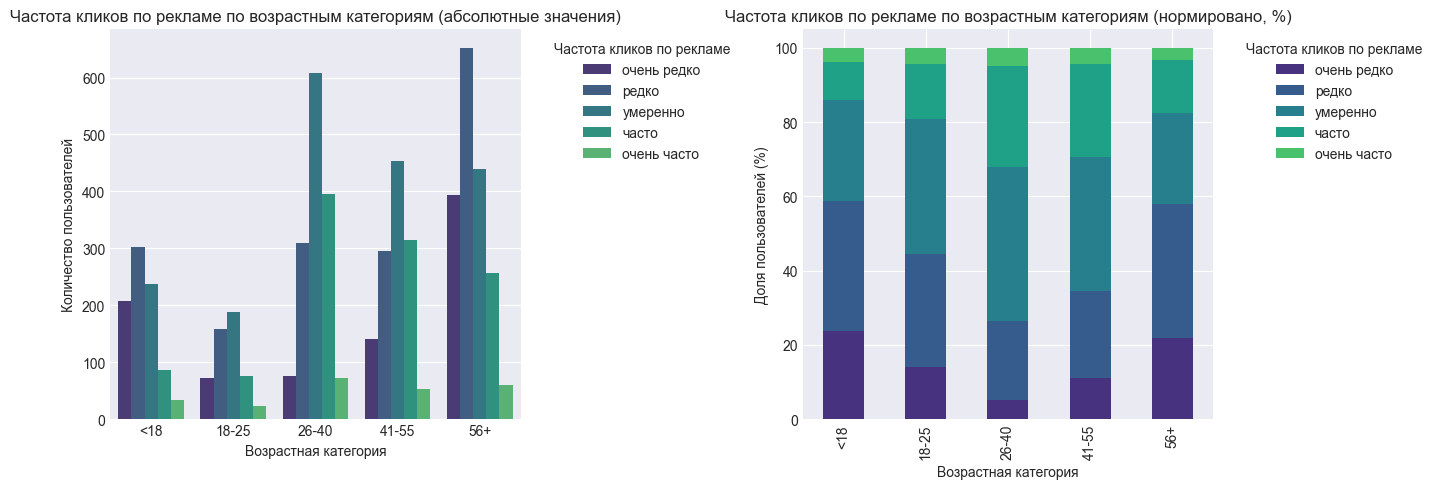

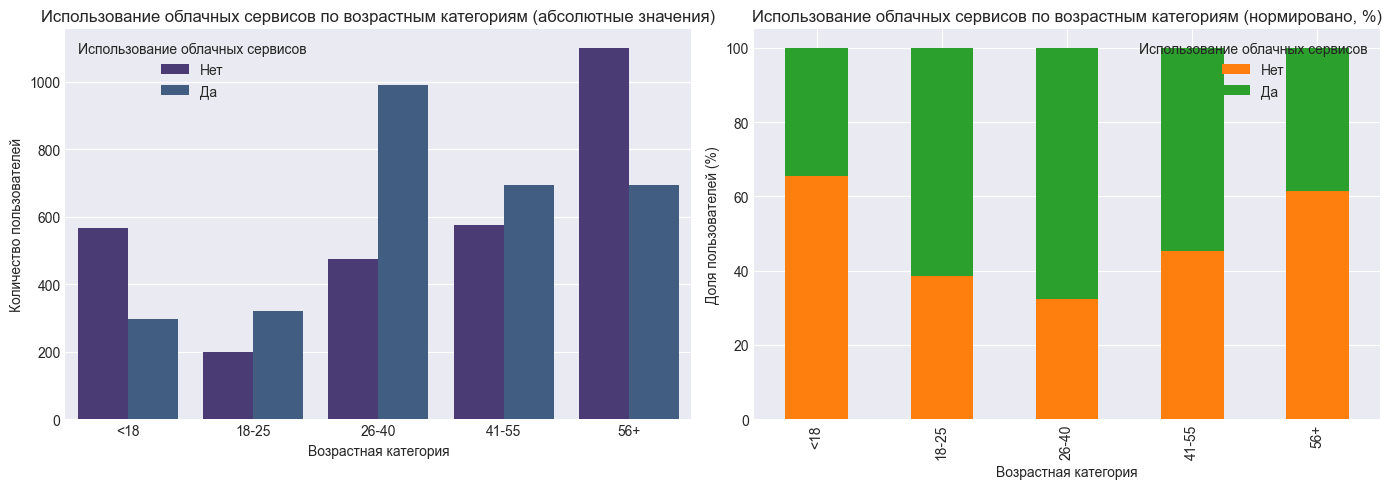

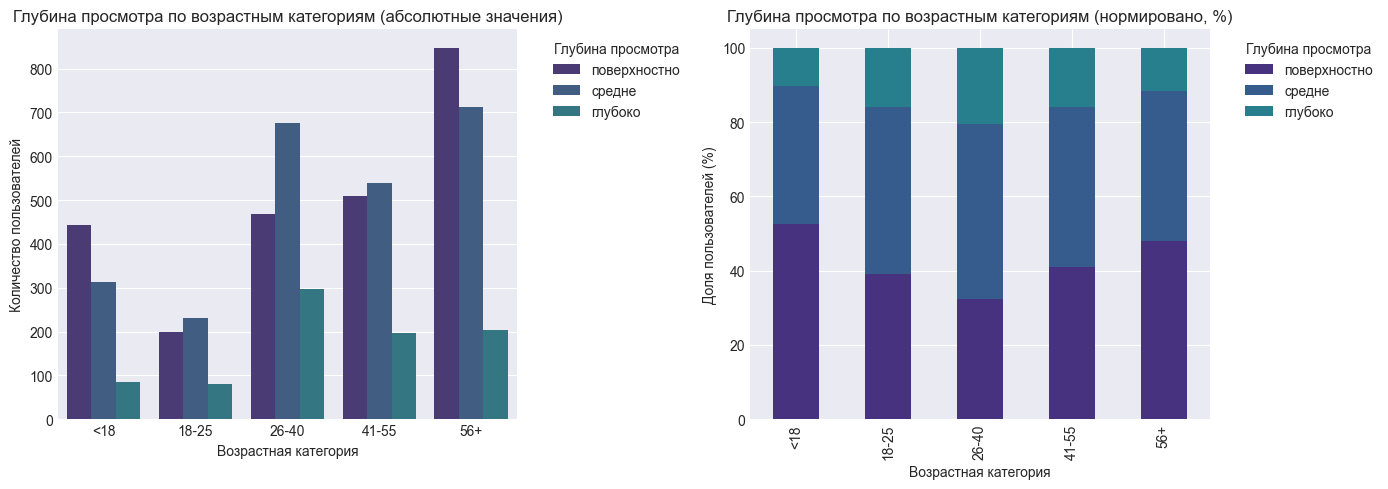

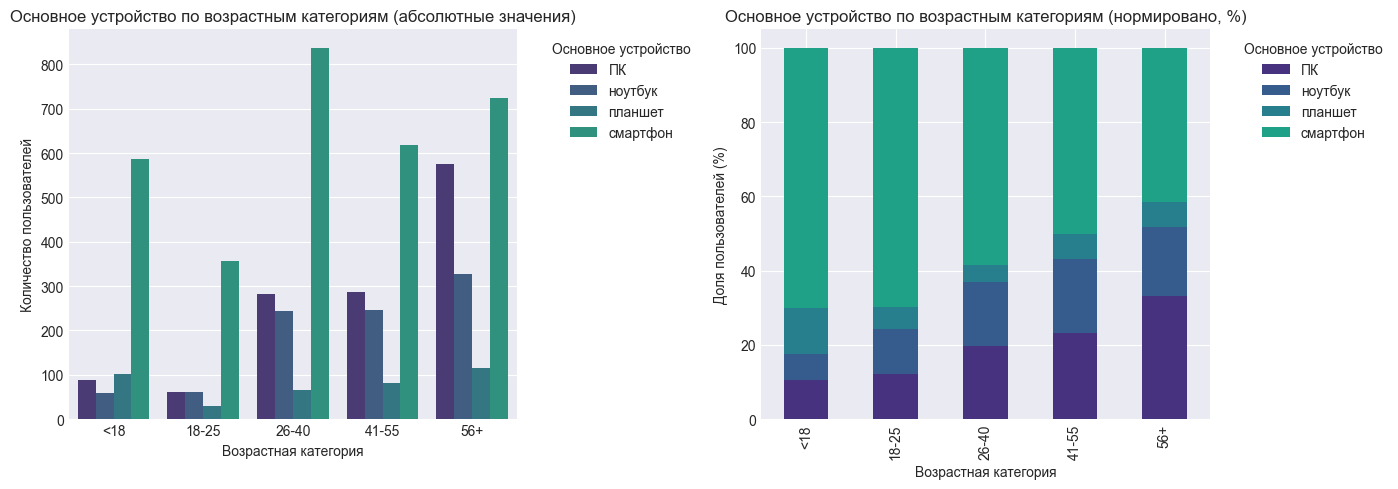

In [73]:
# Анализ ads_activity (частота кликов по рекламе)
order_ads = ['очень редко', 'редко', 'умеренно', 'часто', 'очень часто']
plot_categorical_feature(users, ads, 'ads_activity', 'Частота кликов по рекламе',order=order_ads)

# Анализ cloud_usage (использование облачных сервисов)
plot_binary_feature(users, cloud, 'cloud_usage', 'Использование облачных сервисов',fillna_value=False)

# Анализ surf_depth (глубина просмотра)
order_depth = ['поверхностно', 'средне', 'глубоко']
plot_categorical_feature(users, surf, 'surf_depth', 'Глубина просмотра', order=order_depth)

# Анализ primary_device (основное устройство) — только топ-5 устройств
plot_categorical_feature(users, device, 'primary_device', 'Основное устройство', top_n=5)

## [Этап 3. Предобработка данных <a id=3></a>](#content)

## [Этап 4. Создание новых признаков (Feature Engineering) <a id=4></a>](#content)

## [Этап 5. Разделение данных (стратифицированное по пользователям) <a id=5></a>](#content)

## [Этап 6. Предобработка признаков (пайплайн) <a id=6></a>](#content)

## [Этап 7. Отбор признаков <a id=7></a>](#content)

## [Этап 8. Обучение базовой модели (Baseline) <a id=8></a>](#content)

## [Этап 9. Обучение основных моделей и подбор гиперпараметров <a id=9></a>](#content)

## [Этап 10. Оценка на тестовой выборке <a id=10></a>](#content)

## [Этап 11. Подготовка артефактов для внедрения <a id=11></a>](#content)

## [Этап 12. Итоговый отчёт <a id=12></a>](#content)